## Part1: Linear regression with Pytorch
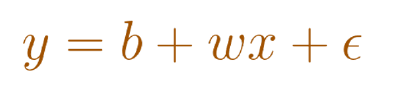

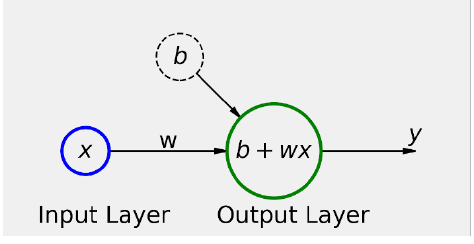

In [2]:
#pip install torchviz

In [4]:
#pip install graphviz

In [7]:
#pip install numpy

In [10]:
#pip install matplotlib

In [13]:
#pip install scikit-learn

In [15]:
#pip install torch torchvision torchaudio

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import torch
import torch.optim as optim
import torch.nn as nn
from torchviz import make_dot

### Data generation
Generate 100 points x and calculate y with b = 1, w = 2 and gaussian noise


In [17]:
N = 100
b = 1
w = 2

In [18]:
np.random.seed(42)
x = np.random.rand(N,1)
epsilone = (.1 * np.random.randn(N, 1))
y = b + w*x + epsilone


### Create train and validation data

In [19]:
# Shuffles the indices
idx = np.arange(N)
print(idx)
np.random.shuffle(idx)
print(idx)
# Uses first 80 random indices for train
train_idx = idx[:int(N*.8)]
print(train_idx)
# Uses the remaining indices for validation
val_idx = idx[int(N*.8):]
print(val_idx)
# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[76 83 80 98  2 77 71 84 89 50 40 51 67 86 37 49  4 10 69 81  9 54 55 87
 64 44 90 75 33 30 93 95 14 61 11 13 15  7  0 19 35  6 12 65 70 88 56 58
 28 38 91 42  8 73 39 85 25 92 41 26  1 22 21 46 74 79 78 72 57 53 24 17
 66 32 31 62 59 52 82 23 36  5 45 99 43 16 48 94 34  3 18 47 60 68 63 27
 96 29 20 97]
[76 83 80 98  2 77 71 84 89 50 40 51 67 86 37 49  4 10 69 81  9 54 55 87
 64 44 90 75 33 30 93 95 14 61 11 13 15  7  0 19 35  6 12 65 70 88 56 58
 28 38 91 42  8 73 39 85 25 92 41 26  1 22 21 46 74 79 78 72 57 53 24 17
 66 32 31 62 59 52 82 23]
[36  5 45 99 43 16 48 94 34  3 18 47 60 68 63 27 96 29 20 97]


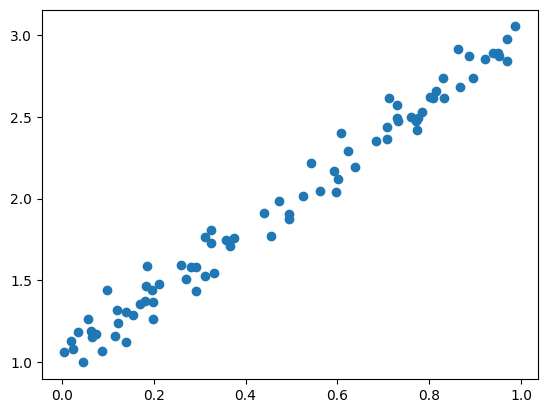

In [20]:
# Represent the data by a scatter plot
plt.scatter(x_train,y_train)

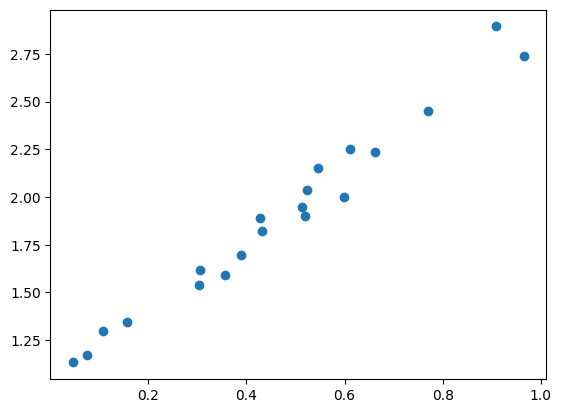

In [21]:
plt.scatter(x_val,y_val)

## Gradient Descent

#### Weights initialization

In [22]:
# Step 1: Weights initialization
np.random.seed(42)
w = np.random.randn(1)
b = np.random.randn(1)
print(b,w)

[-0.1382643] [0.49671415]


#### Computation of the prediction function

In [23]:
# Prediction_ pass forward
y_hat = x_train*w +b

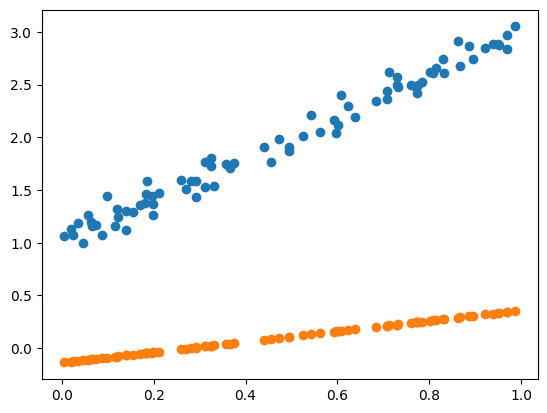

In [24]:
plt.scatter(x_train,y_train)
plt.scatter(x_train,y_hat)

#### Computation of the error per input

$$
\Large \text{error}_i = \hat{y_i} - y_i
$$

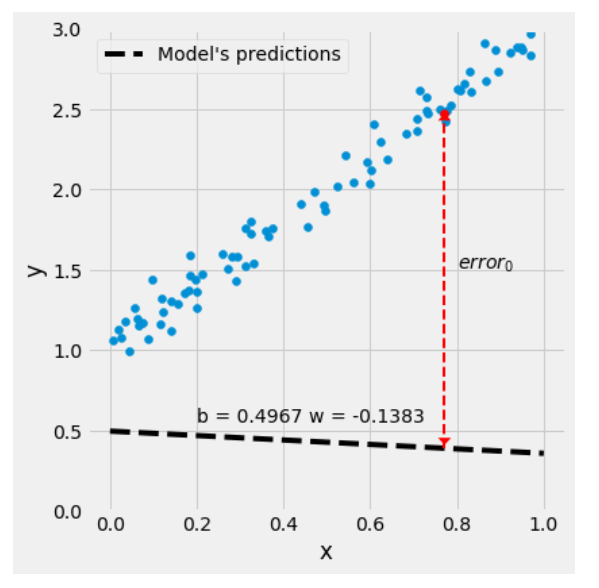

Computation of the loss function

$$
\Large
\begin{aligned}
\text{MSE} &= \frac{1}{n} \sum_{i=1}^n{\text{error}_i}^2
\\
&= \frac{1}{n} \sum_{i=1}^n{(\hat{y_i} - y_i)}^2
\\
&= \frac{1}{n} \sum_{i=1}^n{(b + w x_i - y_i)}^2
\end{aligned}
$$

In [25]:
error = y_hat-y_train
loss_fn = (error**2).mean()
#print(error)

In [26]:
print(error)
print(loss_fn)

[[-2.22970163]
 [-1.29946603]
 [-2.62233292]
 [-1.20414559]
 [-2.24783651]
 [-1.27279995]
 [-1.30494511]
 [-1.50829146]
 [-1.88941641]
 [-2.49677352]
 [-1.31825148]
 [-2.24688073]
 [-2.36265905]
 [-2.3509305 ]
 [-1.53141762]
 [-1.63519895]
 [-1.35083773]
 [-1.26074889]
 [-2.70001975]
 [-2.12264285]
 [-2.15252408]
 [-1.88201253]
 [-2.53096109]
 [-2.01462719]
 [-1.58333517]
 [-1.60638778]
 [-1.40025465]
 [-2.26881528]
 [-2.55726591]
 [-2.24019647]
 [-1.90665075]
 [-1.7989992 ]
 [-1.42130696]
 [-1.51397331]
 [-2.62919117]
 [-1.50879742]
 [-1.5108382 ]
 [-2.38854762]
 [-1.71000987]
 [-1.42971345]
 [-2.35086521]
 [-1.37336998]
 [-2.33668752]
 [-2.08480592]
 [-2.17547386]
 [-2.56833627]
 [-1.16506346]
 [-1.11431142]
 [-2.01270417]
 [-2.14762603]
 [-2.40015439]
 [-1.30424236]
 [-1.96106263]
 [-2.39383439]
 [-1.83009405]
 [-1.70581625]
 [-2.27654368]
 [-2.25740289]
 [-1.76578894]
 [-1.40415962]
 [-2.53755893]
 [-1.57795256]
 [-1.37406897]
 [-1.74713458]
 [-2.22592223]
 [-1.24101348]
 [-1.70644

#### Computation of the gradient

$$
\Large
\begin{aligned}
\frac{\partial{\text{MSE}}}{\partial{b}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{b}} &= \frac{1}{n} \sum_{i=1}^n{2(b + w x_i - y_i)}
\\
&= 2 \frac{1}{n} \sum_{i=1}^n{(\hat{y_i} - y_i)}
\\
\frac{\partial{\text{MSE}}}{\partial{w}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{w}} &= \frac{1}{n} \sum_{i=1}^n{2(b + w x_i - y_i) x_i}
\\
&= 2 \frac{1}{n} \sum_{i=1}^n{x_i (\hat{y_i} - y_i)}
\end{aligned}
$$


In [27]:
b_grad = 2*error.mean()
w_grad = 2*(x_train*error).mean()
print(b_grad)
print(w_grad)

-3.7147657833716528
-2.031191093805243


#### Update the parameters

$$
\Large
\begin{aligned}
b &= b - \eta \frac{\partial{\text{MSE}}}{\partial{b}}
\\
w &= w - \eta \frac{\partial{\text{MSE}}}{\partial{w}}
\end{aligned}
$$


Let's minimize the gradients with the learning rate

In [28]:
alpha = 0.001
b = b - alpha*b_grad
w = w - alpha*w_grad
print(w)
print(b)

[0.49874534]
[-0.13454954]


### Exercise: Repeat the whole process up to 10 epochs and plot the training and validation errors. Compare your results using linear regression with scikit-learn.

An epoch is complete when all the points in the training set have been used for the forward pass, backward pass, and update.  

- **In batch training**, all the data points are used to compute the loss function. One epoch = one update.  
- **In mini-batch training**, updates are made in batches of data. One epoch means all batches have been used. The number of updates is equal to \( N / l \), where \( N \) is the dataset size and \( l \) is the number of batches.  
- **In stochastic gradient descent (SGD)**, an update is made for each individual data point, and an epoch is complete when all data points have been used.

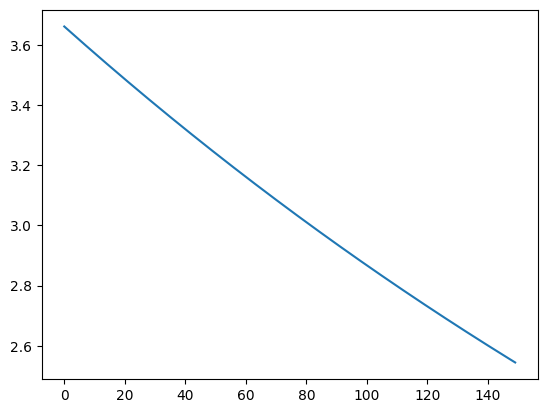

In [40]:
np.random.seed(42)
w = np.random.randn(1)
b = np.random.randn(1)

erreurs = []

n_epoch = 150

alpha = 0.001

for i in range(n_epoch):

  # forward
  y_hat = x_train*w + b

  # error
  erreur = y_hat - y_train

  # calculate the loss
  loss = (erreur**2).mean()

  # calculate gradients
  b_grad = (erreur).mean()
  w_grad = (erreur*x_train).mean()


  # update parameters
  b = b - alpha * b_grad
  w = w - alpha * w_grad

  erreurs.append(loss)

else:
  plt.plot(erreurs)




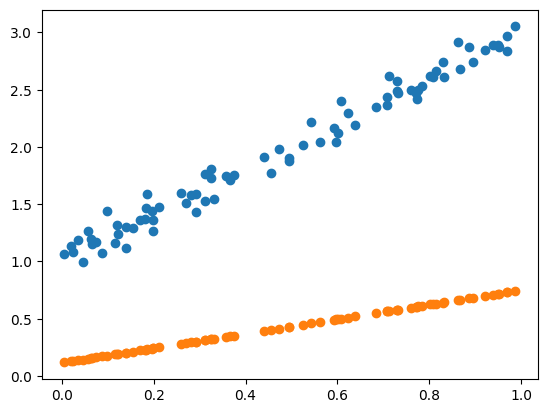

In [41]:
# Use scatter plot
plt.scatter(x_train,y_train)
plt.scatter(x_train,y_hat)

In [42]:
print(b)
print(w)

[0.11575526]
[0.63643175]


#### Compare with scikit-learn


In [43]:
# Use linear regression in scikit-learn
lr = LinearRegression()
lr.fit(x_train,y_train)
print(lr.intercept_,lr.coef_[0])
y_hat = lr.intercept_ + lr.coef_[0]*x_train

[1.02354075] [1.96896447]


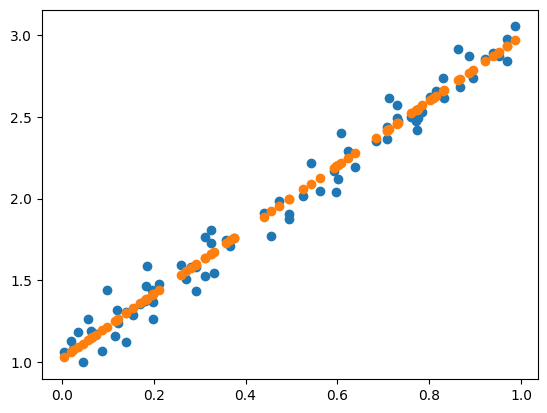

In [44]:
plt.scatter(x_train,y_train)
plt.scatter(x_train,y_hat)

## Part 2: Pytorch

### Neural Frameworks

We have learnt that to train neural networks you need:

* Quickly multiply matrices (tensors)
* Compute gradients to perform gradient descent optimization


What neural network frameworks allow you to do:

* Operate with tensors on whatever computer is available, CPU or GPU, or even TPU
* Automatically compute gradients (they are explicitly programmed for all built-in tensor functions)

Optionally:

* Neural Network constructor / higher level API (describe network as a sequence of layers)

* Simple training functions (fit, as in Scikit Learn)

* A number of optimization algorithms in addition to gradient descent
Data handling abstractions (that will ideally work on GPU, too)

### Most Popular Frameworks

* Tensorflow 1.x - first widely available framework (Google). Allowed to define static computation graph, push it to GPU, and explicitly evaluate it
* PyTorch - a framework from Facebook that is growing in popularity
* Keras - higher level API on top of Tensorflow/PyTorch to unify and simplify using neural networks (Francois Chollet)
* Tensorflow 2.x + Keras - new version of Tensorflow with integrated Keras functionality, which supports **dynamic computation graph**, allowing to perform tensor operations very similar to numpy (and PyTorch)

In this Notebook, we will learn to use PyTorch. You need to make sure that you have recent version of PyTorch installed - to do it, follow the [instructions on their site](https://pytorch.org/get-started/locally/). It is normally as simple as doing
```
pip install torch torchvision
```
or
```
conda install pytorch -c pytorch
```

[Difference between CPU and GPU](https://www.youtube.com/watch?v=-P28LKWTzrI)

In [ ]:
import torch
import torchvision

### Basic Concepts: Tensor

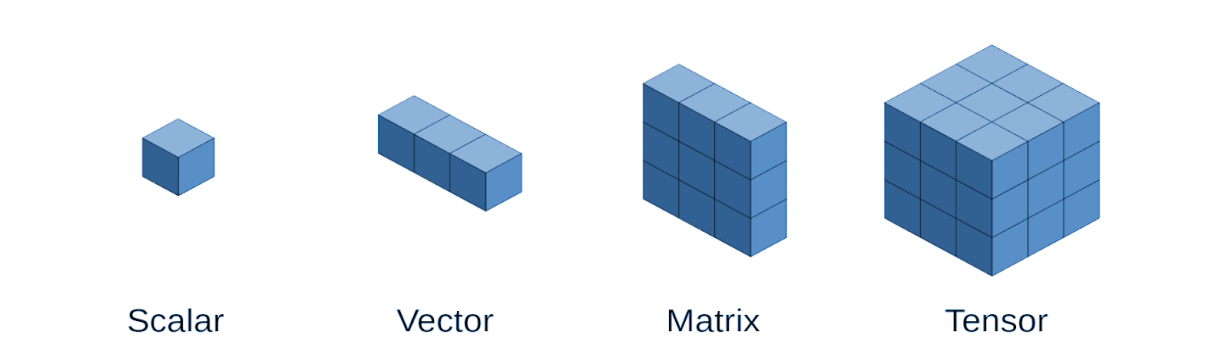

**Tensor** is a multi-dimensional array. It is very convenient to use tensors to represent different types of data:
* 400x400 - black-and-white picture
* 400x400x3 - color picture
* 16x400x400x3 - minibatch of 16 color pictures
* 25x400x400x3 - one second of 25-fps video
* 8x25x400x400x3 - minibatch of 8 1-second videos

#### Simple Tensors

You can easily create simple tensors from lists of np-arrays, or generate random ones:

In [ ]:
scalar = torch.tensor(3.14159)
vector = torch.tensor([1, 2, 3])
matrix = torch.ones((2, 3), dtype=torch.float)
tensor = torch.randn((2, 3, 4), dtype=torch.float)
print(scalar)
print(vector)
print(matrix)
print(tensor)

a = torch.tensor([[1,2],[3,4]])
print(a)
a = torch.randn(size=(10,3))
print(a)

In [ ]:
torch.sum(a,axis=1)

You can get the shape using size() function or shape attribute

In [ ]:
print(tensor.size(), tensor.shape)

You can use arithmetic operations on tensors, which are performed element-wise, as in numpy. Tensors are automatically expanded to required dimension, if needed. To extract numpy-array from tensor, use `.numpy()`:

In [ ]:
print(a-a[0])
print(torch.exp(a)[0].numpy())

### In-place and out-of-place Operations

Tensor operations such as `+`/`add` return new tensors. However, sometimes you need to modify the existing tensor in-place. Most of the operations have their in-place counterparts, which end with `_`:

In [ ]:
u = torch.tensor(5)
print("Result when adding out-of-place:",u.add(torch.tensor(3)))
print(u)
u.add_(torch.tensor(3))
print("Result after adding in-place:", u)
print(u)
u.add(torch.tensor(3))
print(u)

In [ ]:
### Que fait cet expression et donner son equivalent sous pytorch ???
s = torch.zeros_like(a[0])
print(s)
for i in a:
  s.add_(i)

print(s)

In [ ]:
torch.sum(s,axis=0)

You can read more on PyTorch tensors in the [official documentation](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)

#### Resizing Tensors  

This can be done using `view` or `reshape`.  

- `view` is preferred because it does not create a new tensor. Both tensors share the same data.  
- `reshape` may or may not create a new tensor.

In [ ]:
# We get a tensor with a different shape but it still is
# the SAME tensor
same_matrix = matrix.view(1, 6)
print(matrix)
print(same_matrix)
# If we change one of its elements...
same_matrix[0, 1] = 4.
# It changes both variables: matrix and same_matrix
print(matrix)
print(same_matrix)

In [ ]:
# We can use "clone" method to REALLY copy it into a new one
different_matrix = matrix.view(1, 6).clone().detach()
# Now, if we change one of its elements...
different_matrix[0, 1] = 3.
# The original tensor (matrix) is left untouched!

print(matrix)
print(different_matrix)

#### Convert numpy table to pytorch tensors

Two methods: **as_tensor()** or **from_numpy()**. Both create a tensor that shares the same data as the NumPy array.  

If the NumPy array is modified, the tensor’s data is also modified.  

We can use **torch.tensor()** instead, but with this method, the data is not shared.

In [ ]:
x_train_tens = torch.from_numpy(x_train)

In [ ]:
x_train_tens.requires_grad

In [ ]:
y_train_tens = torch.from_numpy(y_train)

### PyTorch Exercises

#### Exercise 1 — Create basic tensors

1. Create a tensor `a` containing the values `[1, 2, 3, 4]`.
2. Create a tensor `b` of shape `(2, 3)` filled with zeros.
3. Create a tensor `c` of shape `(3, 3)` filled with ones.
4. Create a random tensor `d` of shape `(2, 2)`.

---

#### Exercise 2 — Check shape and type

1. Print the **shape** of tensor `d`.
2. Print the **dtype** of tensor `a`.
3. Convert `a` to float (`torch.float32`).

---

#### Exercise 3 — Create special tensors

1. Create a tensor `e` with values from 0 to 9.
2. Create a tensor `f` with 5 evenly spaced values between 0 and 1.
3. Create a `4x4` identity matrix `g`.

---

#### Exercise 4 — Reshape / View

Given:

```python
x = torch.arange(12)
```

1. Reshape `x` into a matrix of shape `(3, 4)`.
2. Reshape that matrix into a tensor of shape `(2, 2, 3)`.
3. Flatten this tensor back into a vector.

---

#### Exercise 5 — Unsqueeze / Squeeze

1. Create a tensor `y = torch.tensor([1, 2, 3])`.
2. Add one dimension at position 0 using `unsqueeze` → expected shape `(1, 3)`.
3. Add one dimension at position 1 → expected shape `(3, 1)`.
4. Remove unnecessary dimensions using `squeeze`.

---

#### Exercise 6 — Resize for image batch (very useful)

Given a grayscale image tensor:

```python
img = torch.randn(28, 28)
```

1. Add a **channel** dimension to get shape `(1, 28, 28)`.
2. Add a **batch** dimension to get shape `(1, 1, 28, 28)`.

---

#### Exercise 7 — Convert NumPy → Tensor

1. Create a NumPy array:

```python
arr = np.array([[1, 2], [3, 4]])
```

2. Convert it to a PyTorch tensor.
3. Check its `dtype`.
4. Convert this tensor to `float32`.

---

#### Exercise 8 — Convert Tensor → NumPy

1. Create a tensor:

```python
t = torch.tensor([[10, 20], [30, 40]], dtype=torch.float32)
```

2. Convert it to a NumPy array.
3. Print the resulting Python type.

---

#### Exercise 9 — Shared memory warning (important)

1. Create:

```python
arr = np.array([1, 2, 3], dtype=np.float32)
t = torch.from_numpy(arr)
```

2. Modify `arr[0] = 99`.
3. Print `t`. What do you notice?
4. Create an independent copy on the PyTorch side.

---

#### Exercise 10 — Mini challenge (combined)

1. Create a NumPy array of shape `(2, 3)` with values from 1 to 6.
2. Convert it to a PyTorch tensor.
3. Reshape it into `(3, 2)`.
4. Add a batch dimension to get `(1, 3, 2)`.
5. Convert the final result back to NumPy.


### Resume

#### Tensor creation

* `torch.tensor(...)` → create from values
* `torch.zeros(...)`, `torch.ones(...)`, `torch.rand(...)`
* `torch.arange(...)`, `torch.linspace(...)`

#### Resizing / reshaping

* `reshape(...)` → change shape
* `flatten()` → flatten tensor
* `unsqueeze(dim)` → add a dimension
* `squeeze()` → remove dimensions of size 1

#### NumPy ↔ PyTorch

* `torch.from_numpy(arr)` → usually shares memory
* `tensor.numpy()` → convert to NumPy (tensor must be on CPU)
* `torch.tensor(arr)` → creates an independent copy

---






## Part 3: Computational graph in pytorch

Pytorch uses computationnal graph to calculate the gradients

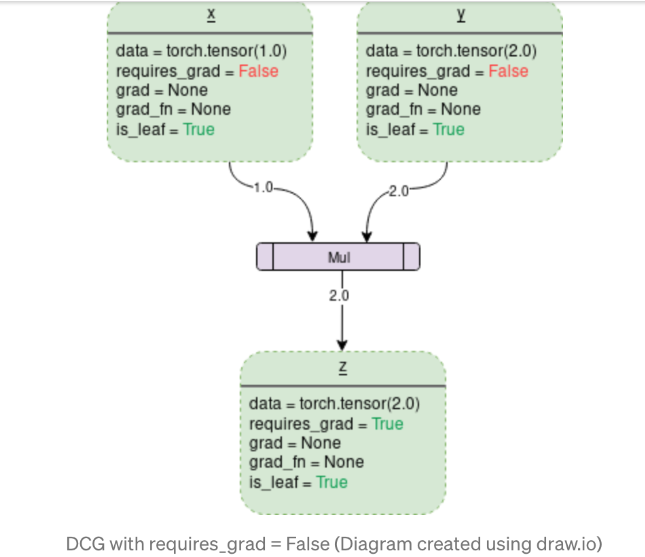

**Data:** This represents the data that a variable holds. `x` contains a 1x1 tensor with a value of 1.0, while `y` is equal to 2.0. `z` holds the product of both, i.e., 2.0.  

**requires_grad:** If this attribute is set to `True`, PyTorch starts tracking all operations performed on the tensor and builds a computational graph for gradient computation. For an arbitrary tensor `a`, it can be modified in-place as follows: `a.requires_grad = True`.  

**grad:** `grad` stores the gradient values. If `requires_grad` is `False`, it will contain `None`. Even if `requires_grad` is `True`, it will remain `None` unless `backward()` is called from another node. For example, if you call `out.backward()` on a variable `out` that involves `x` in its computations, then `x.grad` will contain ∂out / ∂x.  

**grad_fn:** This is the backward function used to compute the gradient.  

**is_leaf:** A node is a leaf if:  
- It was explicitly initialized using a function like `x = torch.tensor(1.0)` or `x = torch.randn(1,1)` (essentially any known tensor initialization method).  
- It was created from operations on tensors where all have `requires_grad = False`.  
- It was created using the `.detach()` method on another tensor.  

When calling `backward()`, gradients are only computed for nodes where both `requires_grad` and `is_leaf` are `True`. These gradients represent derivatives from the output node (where `.backward()` is called) concerning other leaf nodes.  

By setting `requires_grad = True`, PyTorch starts tracking operations and stores gradient functions at each step as follows:

In [ ]:
x = torch.tensor(2.)
y = torch.tensor(10.)

In [ ]:
print(x.requires_grad)
print(x.grad)
print(x.grad_fn)
print(x.is_leaf)
print(x.data)

In [ ]:
print(y.requires_grad)
print(y.grad)
print(y.grad_fn)
print(y.is_leaf)
print(y.data)

In [ ]:
z = x*y

In [ ]:
print(z.requires_grad)
print(z.grad)
print(z.grad_fn)
print(z.is_leaf)
print(z.data)

In [ ]:
z.requires_grad = True

In [ ]:
print(z.requires_grad)
print(z.grad)
print(z.grad_fn)
print(z.is_leaf)
print(z.data)

In [ ]:
z.backward()

In [ ]:
print(x.grad)

In [ ]:
x.requires_grad = True

In [ ]:
z = x*y

In [ ]:
z.backward()

In [ ]:
print(x.grad)

In [ ]:
z.backward()

In [ ]:
print(x.grad)

In [ ]:
print(y.grad)

In [ ]:
K = (x**2)*y

In [ ]:
print(x.requires_grad)
print(x.grad)
print(x.grad_fn)
print(x.is_leaf)
print(x.data)

In [ ]:
print(y.requires_grad)
print(y.grad)
print(y.grad_fn)
print(y.is_leaf)
print(y.data)

In [ ]:
#x.grad = torch.tensor(0.)

In [ ]:
K = (x**2)*y
K.backward()

In [ ]:
print(x.requires_grad)
print(x.grad)
print(x.grad_fn)
print(x.is_leaf)
print(x.data)

In [ ]:
print(y.requires_grad)
print(y.grad)
print(y.grad_fn)
print(y.is_leaf)
print(y.data)

In [ ]:
l = (x**3)*y

In [ ]:
l.backward()

In [ ]:
print(x.requires_grad)
print(x.grad)
print(x.grad_fn)
print(x.is_leaf)
print(x.data)

In [ ]:
x.grad = torch.tensor(0.)

In [ ]:
m = (x**4)*y

In [ ]:
m.backward()

In [ ]:
print(x.requires_grad)
print(x.grad)
print(x.grad_fn)
print(x.is_leaf)
print(x.data)

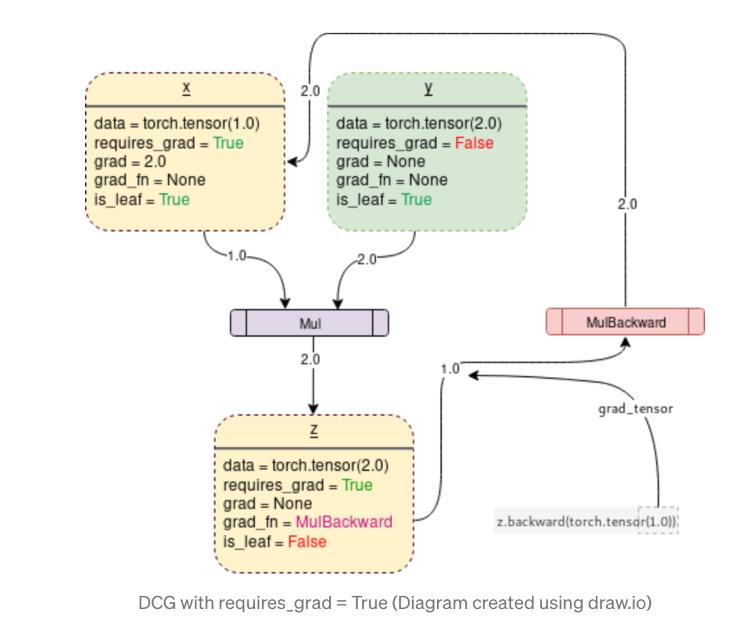

In [ ]:
from torchviz import make_dot

In [ ]:
#On met require_grad à True pour x
x.requires_grad = True
y.requires_grad = True
m = x*x*y*y

In [ ]:
#grad pour x ne contient rien car on n'a pas activé la fonction backward
print(x.requires_grad)
print(x.grad)
print(x.grad_fn)
print(x.is_leaf)
print(x.data)


In [ ]:
print(y.requires_grad)
print(y.grad)
print(y.grad_fn)
print(y.is_leaf)
print(y.data)

In [ ]:
print(m.requires_grad)
print(m.grad)
print(m.grad_fn)
print(m.is_leaf)
print(m.data)

In [ ]:
m.backward(torch.tensor(1.))


In [ ]:
x.grad

In [ ]:
print(y.grad)

In [ ]:
make_dot(m)

Let's take a closer look at these components:  

- **Blue boxes ((1)s):** These boxes represent the tensors we use as parameters, the ones for which we ask PyTorch to compute gradients.  

- **Gray boxes (MulBackward0 and AddBackward0):** These represent Python operations that involve a tensor with gradient computation or its dependencies.  

- **Green box ((3)):** This is the tensor used as the starting point for gradient computation (assuming the `backward()` method is called from the variable used to visualize the graph). Gradients are computed from bottom to top in the graph.  

If a parameter no longer requires a gradient, the computation graph changes accordingly.

**We can use `no_grad` to stop gradient computation when it is not needed. This allows performing regular Python operations on PyTorch tensors without affecting the computation graph.**

In [ ]:
# Check if tracking is enabled
print(x.requires_grad) #True
t = x * 2
print(t.requires_grad) #True

with torch.no_grad():
	# Check if tracking is enabled
	l = x * 2
	print(l.requires_grad) #False

**Resume for Autograd **
Internally, autograd represents this graph as a graph of `Function` objects, which can be applied to compute the result of evaluating the graph. During the forward pass, autograd simultaneously performs the requested computations and constructs a graph representing the function that computes the gradient (the `.grad_fn` attribute of each tensor is an entry point into this graph). Once the forward pass is complete, the graph is evaluated in the backward pass to compute gradients.  

As mentioned earlier, computation graphs in PyTorch are dynamic and are therefore rebuilt from scratch at each iteration. This is exactly what allows the use of arbitrary Python control flow statements that can change the overall shape and size of the graph at each iteration. You don’t need to encode all possible paths before starting training—what you execute is what gets differentiated.  

Each primitive autograd operator consists of two functions that operate on tensors. The forward function computes the output tensors from the input tensors. The backward function receives the gradient of the output tensors with respect to a scalar and computes the gradient of the input tensors with respect to the same scalar.  

Tensors and functions are interconnected and form a directed acyclic graph (DAG), which encodes a complete history of the computation. Each tensor has a `.grad_fn` attribute that references the function that created the tensor (except for tensors created by the user, as their `.grad_fn` is `None`). If you want to compute derivatives, you can call `.backward()` on a tensor. After calling the `backward` function, the gradient values are stored as tensors in the `grad` attribute.



### Part 4:  Send to GPUS if they exist GPU

So far, we have only created CPU tensors. What does it mean? It means the data in
the tensor is stored in the computer’s main memory and any operations performed
on it are going to be handled by its CPU (the Central Processing Unit, for instance, an Intel® Core™ i7 Processor). So, although the data is, technically speaking, in the
memory, we’re still calling this kind of tensor a CPU tensor.



There is also a GPU tensor. A GPU (which stands for Graphics Processing Unit)
is the processor of a graphics card. These tensors store their data in the graphics
card’s memory and operations on top of them are performed by the GPU. For more
information on the differences between CPUs and GPUs, please refer to this [link](https://blogs.nvidia.com/blog/2009/12/16/whats-the-difference-between-a-cpu-and-a-gpu/)
.
If you have a graphics card from NVIDIA, you can use the power of its GPU to
speed up model training. PyTorch supports the use of these GPUs for model
training using CUDA (Compute Unified Device Architecture), which needs to be
previously installed and configured (please refer to the Setup Guide for more
information on this).
If you do have a GPU (and you managed to install CUDA), we’re getting to the part
where you get to use it with PyTorch. But, even if you do not have a GPU,  you can use a free GPU
from Google Colab or Kaggle and, second, you should always make your code GPU-ready,
that is, it should automatically run in a GPU, if one is available.


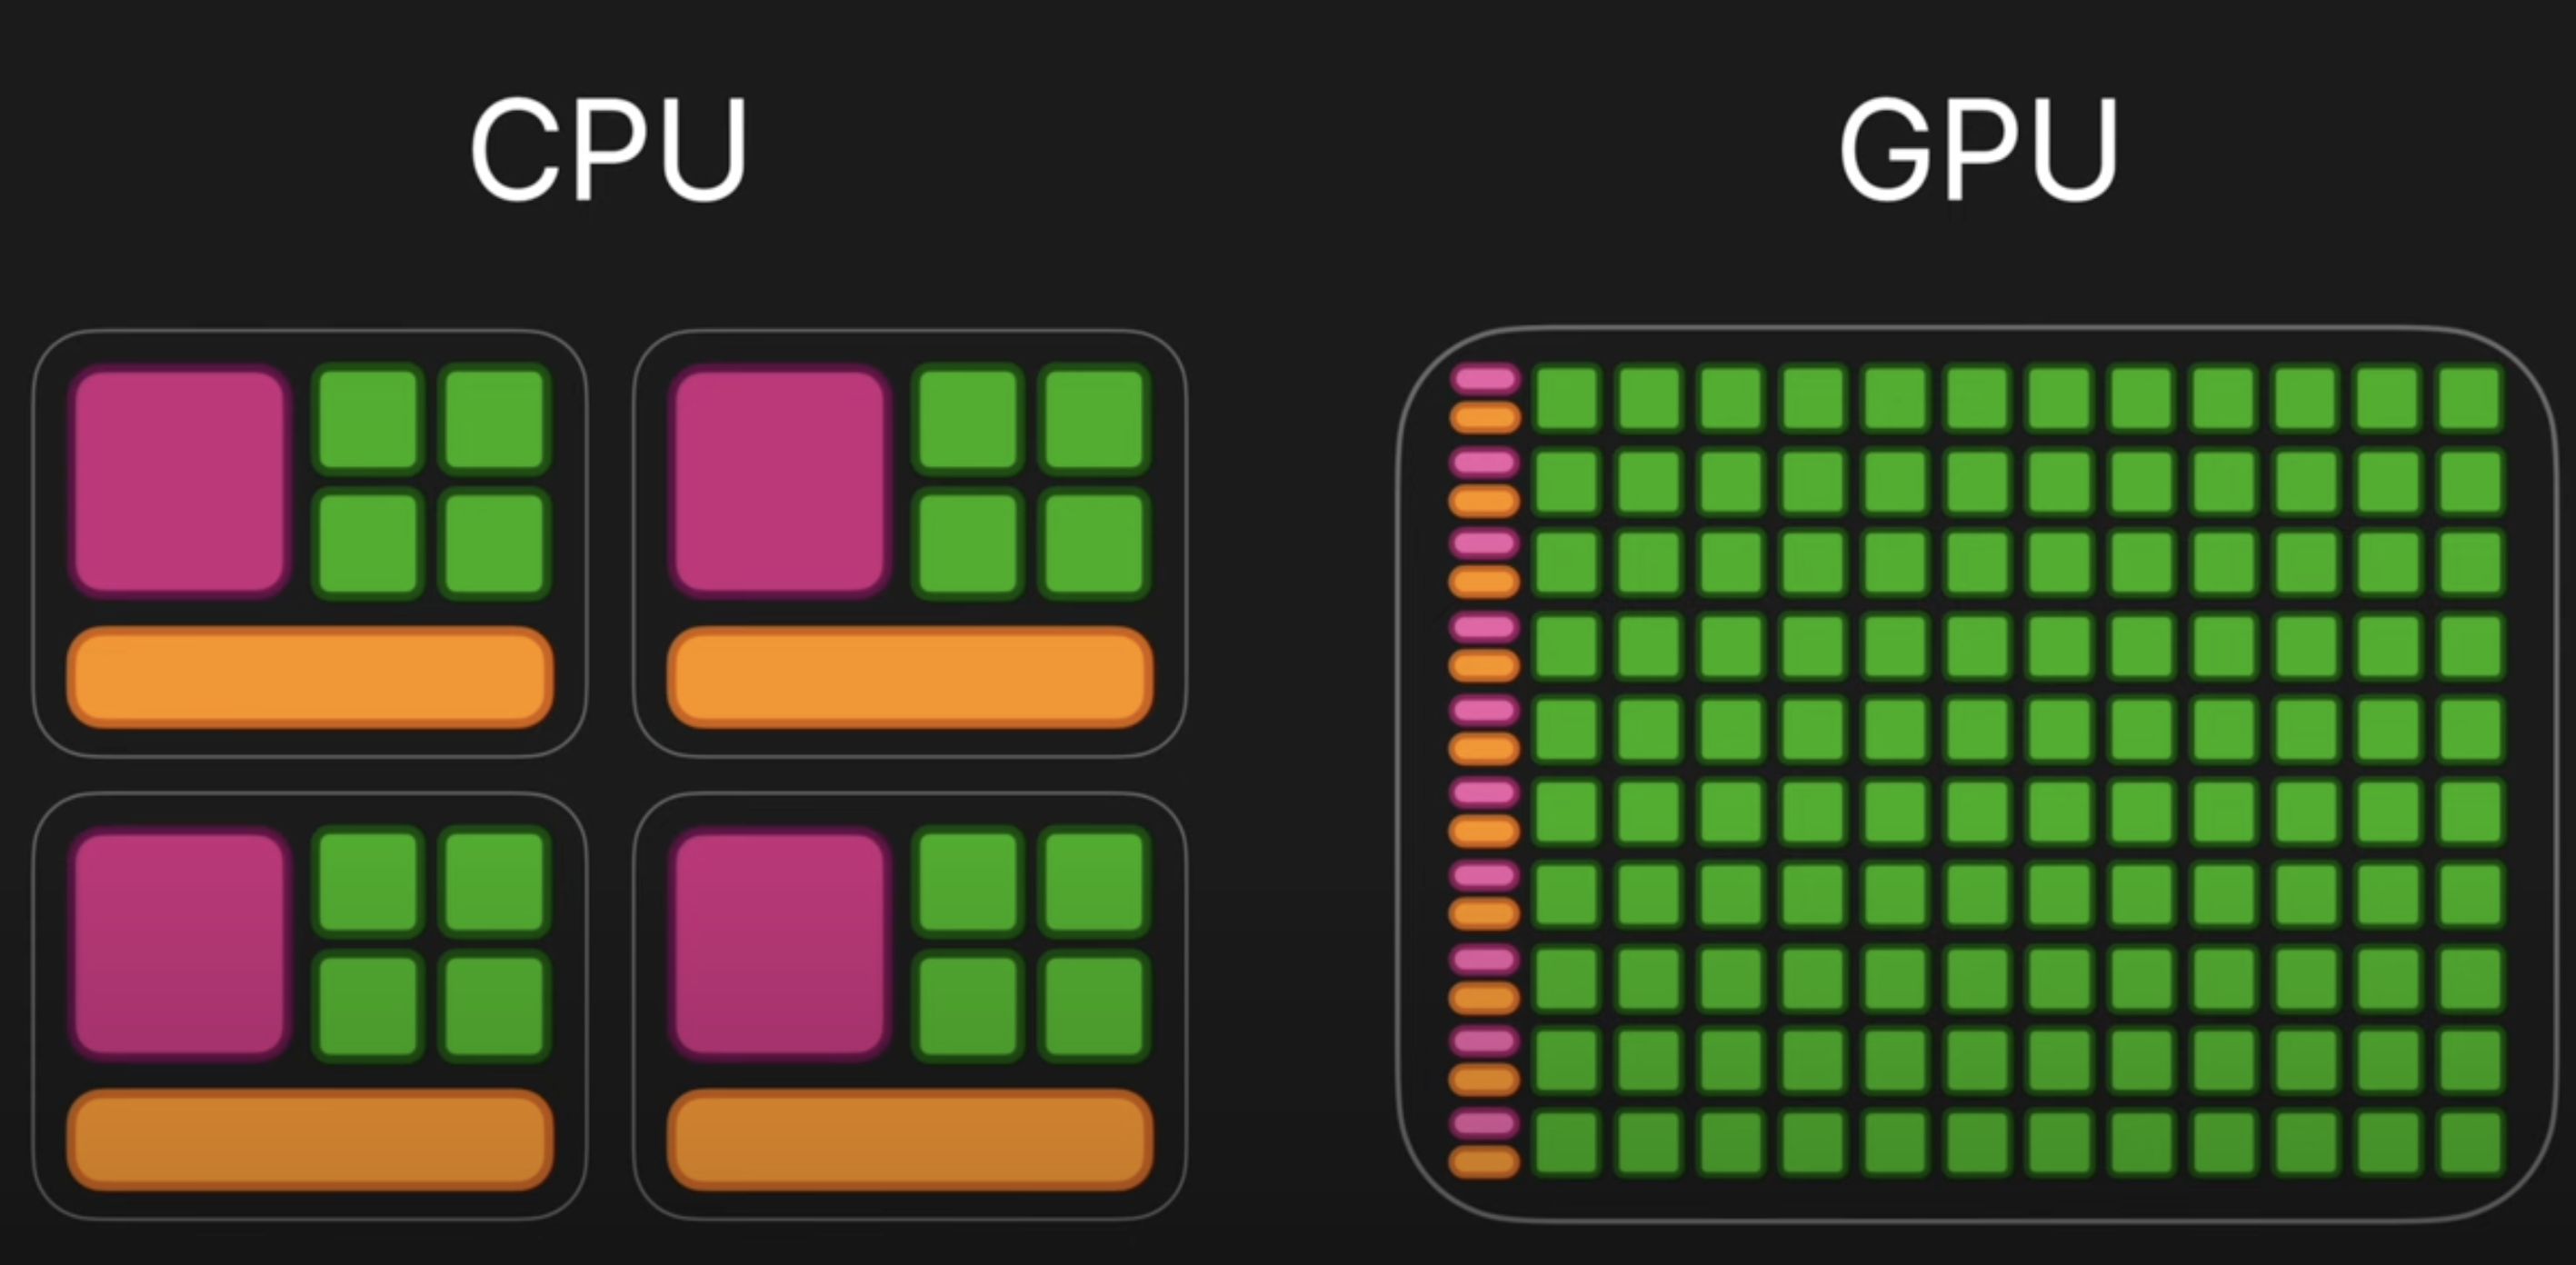

In [ ]:
import torch
# You can define your device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Get the number of device
n_cudas = torch.cuda.device_count()
print(n_cudas)
print(device)
for i in range(n_cudas):
    print(torch.cuda.get_device_name(i))


If you don’t have a GPU, the device is called `cpu`; otherwise, it is called `cuda`. You can have multiple GPUs, so they will be indexed as `cuda:0`, `cuda:1`, and so on.

In [ ]:
# Send data to your device
devices = 'cpu'
if torch.cuda.is_available():
  devices = torch.cuda.current_device()
  print("here")
  x_train_tens = x_train_tens.cuda()
  y_train_tens = y_train_tens.cuda()

In [ ]:
print(devices)

In [ ]:
print(type(x_train), x_train_tens.device, x_train_tens.type())

**Note:**  

However, NumPy cannot handle GPU tensors, so you cannot directly convert a PyTorch GPU tensor into a NumPy tensor. You must first convert it to a CPU tensor.

In [ ]:
 # Doesn't work with a  GPU tensor
#back_to_numpy = x_train_tens.numpy()
# Convert the tensor to  cpu
back_to_numpy = x_train_tens.cpu().numpy()

#### How to create parameters ?

Three bad practices to avoid:

In [ ]:
# Bad: because this will give you CPU tensors so won't work if you are using GPU
torch.manual_seed(42)
b1 = torch.randn(1, requires_grad=True, dtype=torch.float)
w1 = torch.randn(1, requires_grad=True, dtype=torch.float)


print(b1)
print(w1)

In [ ]:
print(b1.device)

In [ ]:
# OLD: let's use the to function to affect the device but this masks the requires_grad
# Does not exist anymore ?
torch.manual_seed(42)
b2 = torch.randn(1,requires_grad = True, dtype = torch.float).to(device)
w2 = torch.randn(1,requires_grad = True, dtype = torch.float).to(device)
print(b2)
print(w2)

In [ ]:
print(b2.requires_grad)

In [ ]:
# Pas mal: on envoie d'abord les données à un device avant de mettre le require_grad à true
b3 = torch.randn(1, dtype = torch.float).to(device)
w3 = torch.randn(1, dtype = torch.float).to(device)

b3.requires_grad_()
w3.requires_grad_()
print(b3)
print(w3)

##### Best Solution  

We create the parameters by:  

* Setting their `requires_grad` to `True` so that gradient computations are done automatically.  
* Assigning them to a device (this should always be done at the time of creation).

In [ ]:
b = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
w = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)

In [ ]:
print(b)

#### Autograd

We no longer need to worry about calculating derivatives. PyTorch does it for us using the `backward()` function mentioned earlier. We need to call it with the `Loss` variable.

In [ ]:
y_hat_tens = b + w*x_train_tens

In [ ]:
erreur = y_hat_tens - y_train_tens

In [ ]:
loss = 2*(erreur**2).mean()

In [ ]:
# Step 3 - Computes gradients for both "b" and "w" parameters
# No more manual computation of gradients!
# b_grad = 2 * error.mean()
# w_grad = 2 * (x_tensor * error).mean()
loss.backward()

Which tensors are going to be handled by the backward() method applied to the
loss?
* b
* w
* yhat
* error


We have set requires_grad=True to both b and w, so they are obviously included in
the list. We use them both to compute yhat, so it will also make it to the list. Then
we use yhat to compute the error, which is also added to the list.
Do you see the pattern here? If a tensor in the list is used to compute another
tensor, the latter will also be included in the list. Tracking these dependencies is
exactly what the dynamic computation graph is doing, as we’ll see shortly

In [ ]:
print(y_hat_tens.requires_grad,y_train_tens.requires_grad,x_train_tens.requires_grad,b.requires_grad,w.requires_grad)

What about x_train_tensor and y_train_tensor? They are involved in the
computation too… but we created them as not gradient-requiring tensors, so
backward() does not care about them

In [ ]:
print(b.grad,w.grad)

In [ ]:
make_dot(loss)

**Note:** Gradients are accumulated with each execution of the previous codes. This means that if you run cells 90 to 91, the gradients will be accumulated.

In [ ]:
# To avoid gradient accumulation, we set the gradients to zero at each execution of the previous cells.

b.grad.zero_()
w.grad.zero_()

#### Training process

In [ ]:
print(b.grad)

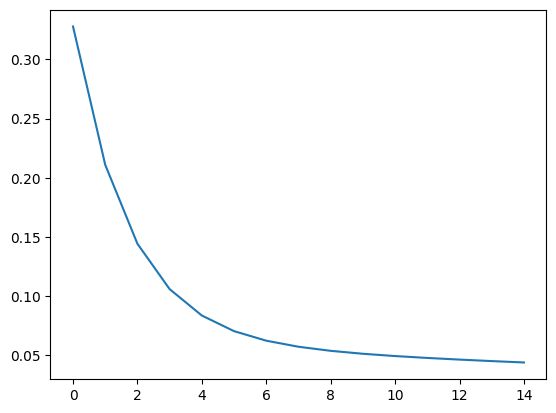

In [ ]:
torch.manual_seed(53)
b = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
w = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
erreurs = []

n_epoch = 15

alpha = 0.1

for i in range(n_epoch):

  # forward phase
  y_hat_tens = x_train_tens*w + b

  # calculate the errors
  erreur_tens = (y_hat_tens - y_train)
  # calculate the loss function
  loss_tens = (error_tens**2).mean()


  # do backpropagation
  loss_tens.backward()


  # Update the parameters with the gradients
  b = b - alpha*b.grad
  w = w - alpha*w.grad
  erreurs.append(loss_tens.cpu().detach().numpy())


  # eliminate gradients in order to avoid gradient accumulation

  b.grad.zero_()
  w.grad.zero_()



else:
  plt.plot(erreurs)



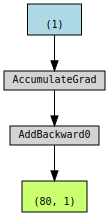

In [ ]:
b_nograd = torch.randn(1, requires_grad=True, dtype=torch.float, device=devices)
w = torch.randn(1, requires_grad=False, dtype=torch.float, device=devices)
yhat = b_nograd + w * x_train_tens
make_dot(yhat)

Let's take a closer look at these components:  
* Blue boxes ((1)s): These boxes correspond to the tensors we use as parameters, the ones we ask PyTorch to compute the gradients for.  

* Gray boxes (MulBackward0 and AddBackward0): A Python operation that involves a gradient calculation tensor or its dependencies.  

* Green box ((80, 1)): The tensor used as the starting point for gradient calculation (assuming the `backward()` method is called from the variable used to visualize the graph) — they are computed from bottom to top in a graph.


**If we set the `requires_grad` of one of the parameters to `False`, for example, `b`, then we no longer see it in the graph. See the example below.**

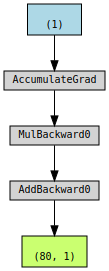

In [ ]:
b_nograd = torch.randn(1, requires_grad=False, dtype=torch.float, device=devices)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=devices)
yhat = b_nograd + w * x_train_tens
make_dot(yhat)

Let's control the gradient flow in the below example:

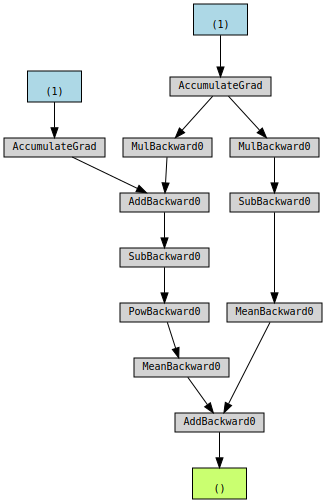

In [ ]:
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=devices)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=devices)
yhat = b + w * x_train_tens
error = yhat - y_train_tens
loss = (error ** 2).mean()
# this makes no sense!!
if loss > 0:
  yhat2 = w * x_train_tens
  error2 = yhat2 - y_train_tens
# neither does this :-)
loss += error2.mean()
make_dot(loss)

Even though the computation is nonsensical, you can clearly see the effect of
adding a control flow statement like if loss > 0: it branches the computation
graph in two parts. The right branch performs the computation inside the if
statement, which gets added to the result of the left branch in the end.




##  Part 5:  Optimizer

There are many optimizers: SGD is the most basic of them, and Adam is one of the most popular. Different optimizers use different mechanisms to update the parameters, but they all achieve the same goal through different paths.

**Do not confuse the optimizer name SGD with stochastic gradient descent. SGD is just a name, but if you use all the data, you are performing Batch Gradient Descent.**

Instead of manually updating and resetting the gradients to zero, we use an optimizer to do it. We replace this part:



```
 # Solution pour les problémes ci-desssus
  with torch.no_grad():

    b -= alpha*b.grad
  
    w -= alpha*w.grad

    erreurs.append(loss_tens.numpy())
    

  # Attention: A la sortie les paramétres perdent le gradient donc grad = None,
  
  b.grad.zero_()
  w.grad.zero_()

```

by:



```
optimizer.step()

optimizer.zero_grad()

```





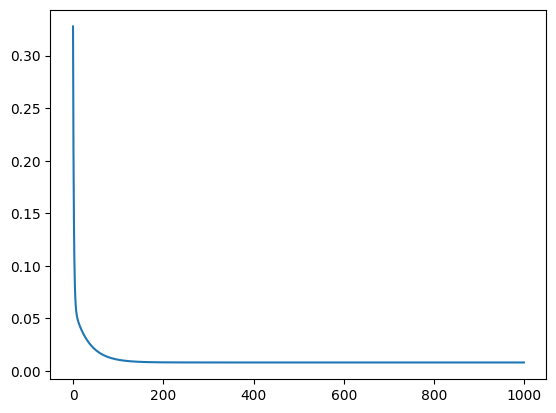

In [ ]:
# the code changes

torch.manual_seed(53)
b = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
w = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
erreurs = []

n_epoch = 1000

alpha = 0.1


optimizer = optim.SGD([b,w],lr = alpha)


for i in range(n_epoch):

  y_hat_tens = w * x_train_tens + b

  erreur_tens = (y_hat_tens - y_train_tens)

  loss_tens = (erreur_tens**2).mean()



  loss_tens.backward()

  optimizer.step()

  erreurs.append(loss_tens.cpu().detach().numpy())


  # Attention: the parameters lose the gradients thenj grad = None,

  optimizer.zero_grad()

else:
  plt.plot(erreurs)



### Fonction Loss
PyTorch provides a set of loss functions with the nn module. In the case of mean squared error, we can use **nn.MSELoss(reduction='mean')**.

* **MSELoss** is not a function in itself that receives predictions and labels. It is a higher-order function, so it generates another function that we will call **loss_fn**.

* We can also add a reduction function like the mean function in our case.

In [ ]:
def multiply(n):
  def with_values(x):
    return x*n
  return with_values

In [ ]:
val = multiply(2)

In [ ]:
print(val)

<function multiply.<locals>.with_values at 0x78fcc4b10ae0>


In [ ]:
val(7)

14

In [ ]:
val(10)

20

In [ ]:
val7 = multiply(7)


In [ ]:
val7

<function __main__.multiply.<locals>.with_values(x)>

In [ ]:
val7(3)

21

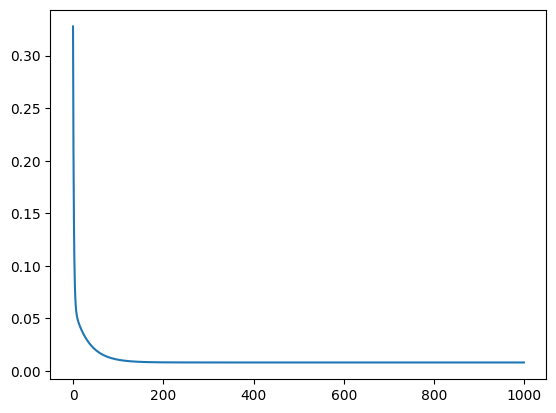

In [ ]:
# the code changes

torch.manual_seed(53)
b = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
w = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
erreurs = []

n_epoch = 1000

alpha = 0.1

optimizer = optim.SGD([b,w],lr = alpha)

#loss_fn  = nn.MSELoss(reduction = 'mean')
loss_fn  = nn.MSELoss(reduction='mean')
for i in range(n_epoch):

  y_hat_tens = w * x_train_tens + b

  #erreur_tens = (y_hat_tens - y_train_tens)

  #loss_tens = (erreur_tens**2).mean()

  loss_tens = loss_fn(y_hat_tens , y_train_tens)



  loss_tens.backward()

  optimizer.step()

  #erreurs.append(loss_tens.detach().numpy())

  # On peut transformer le tenseur en liste au lieu d'avoir à le detacher du graphe de calcul c'est plus simple

  erreurs.append(loss_tens.tolist())
  # Ou erreurs.append(loss_tens.item())


  # Attention: A la sortie les paramétres perdent le gradient donc grad = None,

  optimizer.zero_grad()

else:
  plt.plot(erreurs)

## Model Creation

This is the most delicate part. You need to start by:

* Calling the **__init__** method of the nn class, which is the parent class.

* Initializing the parameters **b** and **w** in the **__init__()** function of the class. It is important to wrap them with the **nn.Parameter** class to make them model parameters. This allows:

> To use the **parameters()** method of the model to access all the parameters.

> To use the **state_dict()** method to access the current values of the parameters. This method returns a dictionary that only contains the parameters involved in learning. It should not be confused with the **state_dict()** of the optimizer, which also contains hyperparameters.

* Implementing the **forward(self, x)** method, which provides a prediction from the model given the input **x**.



In [ ]:
# linear regression model

class ManuelRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.b = nn.Parameter(torch.randn(1,requires_grad = True,dtype = torch.float))
    self.w = nn.Parameter(torch.randn(1,requires_grad = True,dtype = torch.float))

  def forward(self,x):
    y = self.w * x + self.b
    return y

[Parameter containing:
tensor([1.0235], requires_grad=True), Parameter containing:
tensor([1.9690], requires_grad=True)]


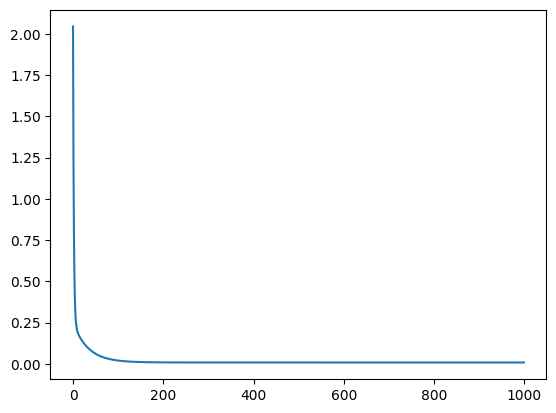

In [ ]:
# the code changes

torch.manual_seed(53)
# It is important to send the model to the device where the data is located
model = ManuelRegression().to(devices)

# b = torch.tensor(1, requires_grad=True, dtype=torch.float, device=devices)
# w = torch.tensor(1, requires_grad=True, dtype=torch.float, device=devices)
errors = []

n_epoch = 1000

alpha = 0.1

optimizer = optim.SGD(model.parameters(), lr=alpha)

loss_fn = nn.MSELoss(reduction='mean')

for i in range(n_epoch):
  # Attention: this just sets the model to training mode and not evaluation mode. For example, dropout is only applied during training
  model.train()

  # We do not call the forward() method but just the model
  y_hat_tens = model(x_train_tens)

  # error_tens = (y_hat_tens - y_train_tens)

  # loss_tens = (error_tens**2).mean()

  loss_tens = loss_fn(y_hat_tens, y_train_tens)

  loss_tens.backward()

  optimizer.step()

  # errors.append(loss_tens.detach().numpy())

  # We can convert the tensor to a list instead of detaching it from the computation graph, it's simpler

  errors.append(loss_tens.tolist())
  # Or errors.append(loss_tens.item())

  # Attention: After this point, the parameters lose their gradient, so grad = None,

  optimizer.zero_grad()

else:
  plt.plot(errors)
  print(list(model.parameters()))


### Let's take the linear model of  pytorch


PyTorch includes a method **Linear(in_features, out_features)** in its **nn** module that allows for the implementation of a linear module. We can rewrite our model.

This linear model can be considered as a layer in a neural network, as shown in the example below."

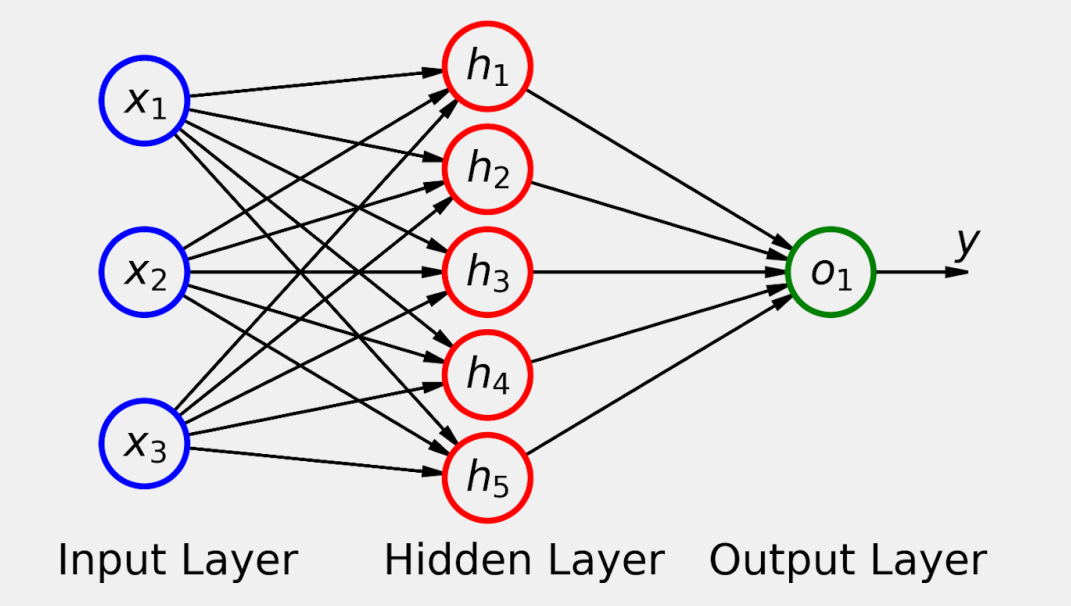


In the figure above, we can represent the hidden layer without the activation function using `nn.Linear(3, 5)` and the output layer without the activation function using `nn.Linear(5, 1)`.

We can also use `nn.Sequential()` which allows us to define the network as a sequence of layers:"



```
# This is formatted as code

torch.manual_seed(42)
# Building the model from the figure above
model = nn.Sequential()
model.add_module('layer1', nn.Linear(3, 5))
model.add_module('layer2', nn.Linear(5, 1))
model.to(device)
```




In our model we can represent it by nn.Linear(1,1).

In [ ]:
class ManuelRegressionNew(nn.Module):
  def __init__(self):
    super().__init__()
    self.lin = nn.Linear(1,1)

  def forward(self,x):
    return self.lin(x)



[Parameter containing:
tensor([[0.4912]], requires_grad=True), Parameter containing:
tensor([0.5226], requires_grad=True)]
[Parameter containing:
tensor([[1.7554]], requires_grad=True), Parameter containing:
tensor([1.1327], requires_grad=True)]


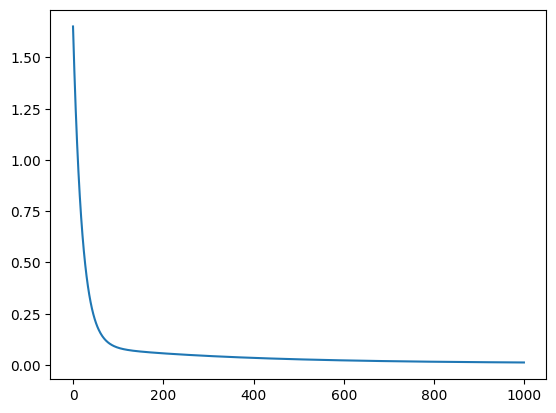

In [ ]:
# the code changes

torch.manual_seed(53)

X, y = x_train_tens.float(), y_train_tens.float()
# It is important to send the model to the device where the data is located
modelnew = ManuelRegressionNew().to(devices).float()

print(list(modelnew.parameters()))

# b = torch.tensor(1, requires_grad=True, dtype=torch.float, device=devices)
# w = torch.tensor(1, requires_grad=True, dtype=torch.float, device=devices)
errors = []

n_epoch = 1000

alpha = 0.01

optimizer = optim.SGD(modelnew.parameters(), lr=alpha)

loss_fn = nn.MSELoss(reduction='mean')

for i in range(n_epoch):
    # Note: This only sets the model to training mode, not evaluation mode. For example, dropout is applied only during training
    modelnew.train()

    # We do not call the forward() method but simply call the model
    y_hat_tens = modelnew(X)

    # error_tens = (y_hat_tens - y_train_tens)

    # loss_tens = (error_tens**2).mean()

    loss_tens = loss_fn(y_hat_tens, y)

    loss_tens.backward()

    optimizer.step()

    # errors.append(loss_tens.detach().numpy())

    # We can convert the tensor to a list instead of having to detach it from the computation graph; this is simpler

    errors.append(loss_tens.tolist())
    # Or errors.append(loss_tens.item())

    # Note: Upon exit, the parameters lose the gradient, so grad = None

    optimizer.zero_grad()

else:
    plt.plot(errors)
    print(list(modelnew.parameters()))


In [ ]:
# The model has a method state_dict() that gives values  of model parameters
modelnew.state_dict()

OrderedDict([('lin.weight', tensor([[1.7554]])),
             ('lin.bias', tensor([1.1327]))])

In [ ]:
# The optimizer has a method state_dict() that contains its internal state and its hyperparameters
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.01,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

There are MANY different layers that can be used in PyTorch:
* Convolution Layers
* Pooling Layers
* Padding Layers
* Non-linear Activations
* Normalization Layers
* Recurrent Layers
* Transformer Layers
* Linear Layers
* Dropout Layers
* Sparse Layers (embeddings)
* Vision Layers
* DataParallel Layers (multi-GPU)
* Flatten Layer

### Jupyter's Magic Commands

`%%writefile`: Allows writing the code from a cell into a file without executing it.

`%run`: Allows executing the mentioned function independently from the rest of the notebook. The `-i` option can be used to make all defined variables available.

For example, you can write the data preparation part in a file named v0.py.



In [ ]:
import torch

In [ ]:
!mkdir data_preparation

In [ ]:
%%writefile data_preparation/v0.py
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Our data was in Numpy arrays, but we need to transform them
# into PyTorch's Tensors and then we send them to the
# chosen device
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

Writing data_preparation/v0.py


In [ ]:
%run -i data_preparation/v0.py

NameError: name 'x_train' is not defined

### Using high order function for the training function

We know that when a model is running, it does not change its optimizer, model, or loss function. We will write a higher-order function based on this information.

In [ ]:
!mkdir model_configuration

In [ ]:
%%writefile model_configuration/v0.py

def training(model, optimizer, loss_fn):
    def training_model_step(X, y):

        # Note: This simply puts the model in training mode, not evaluation mode. For example, dropout is only applied during training.
        model.train()

        # We don't call the forward() method directly, but instead just call the model
        y_hat_tens = model(X)

        # error_tens = (y_hat_tens - y_train_tens)

        # loss_tens = (error_tens**2).mean()

        loss_tens = loss_fn(y_hat_tens, y)

        loss_tens.backward()

        optimizer.step()

        # errors.append(loss_tens.detach().numpy())

        # We can convert the tensor to a list instead of detaching it from the computation graph, which is simpler

        # Note: At the end, the parameters lose their gradient, so grad = None

        optimizer.zero_grad()

        return loss_tens.tolist()

    return training_model_step



Writing model_configuration/v0.py


In [ ]:
%run -i model_configuration/v0.py

In [ ]:

%%writefile model_configuration/v1.py

# code changes

torch.manual_seed(53)

device  = 'cuda' if torch.cuda.is_available() else 'cpu'


model = nn.Sequential(nn.Linear(1,1)).to(device)


#b = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
#w = torch.tensor(1,requires_grad = True, dtype = torch.float,device = devices)
erreurs = []

n_epoch = 1000

alpha = 0.01

optimizer = optim.SGD(model.parameters(),lr = alpha)

loss_fn  = nn.MSELoss(reduction = 'mean')

train = training(model, optimizer,loss_fn)



Writing model_configuration/v1.py


In [ ]:
%run -i model_configuration/v1.py

In [ ]:
train

<function __main__.training.<locals>.training_model_step(X, y)>

In [ ]:
!mkdir model_training

mkdir: cannot create directory ‘model_training’: File exists


In [ ]:

%%writefile model_training/v0.py
epochs = 1000
erreurs = []
for i in range(epochs):
  loss = train(x_train_tensor,y_train_tensor)
  erreurs.append(loss)
print(erreurs)

Overwriting model_training/v0.py


In [ ]:
%run -i model_training/v0.py

[1.650896430015564, 1.5744428634643555, 1.5017262697219849, 1.4325631856918335, 1.3667796850204468, 1.3042103052139282, 1.244696855545044, 1.1880899667739868, 1.1342467069625854, 1.0830321311950684, 1.034316897392273, 0.9879788160324097, 0.9439012408256531, 0.9019731283187866, 0.8620893359184265, 0.824149489402771, 0.7880584001541138, 0.7537253499031067, 0.7210642099380493, 0.6899932026863098, 0.6604341268539429, 0.6323129534721375, 0.605559229850769, 0.5801059007644653, 0.5558892488479614, 0.5328484773635864, 0.5109262466430664, 0.4900675415992737, 0.47022026777267456, 0.45133501291275024, 0.4333643913269043, 0.41626375913619995, 0.3999904990196228, 0.38450390100479126, 0.3697654902935028, 0.35573869943618774, 0.3423885703086853, 0.32968199253082275, 0.31758734583854675, 0.3060747981071472, 0.2951158285140991, 0.2846831679344177, 0.2747511565685272, 0.2652953267097473, 0.2562922537326813, 0.24771973490715027, 0.23955675959587097, 0.23178331553936005, 0.22438032925128937, 0.21732957661

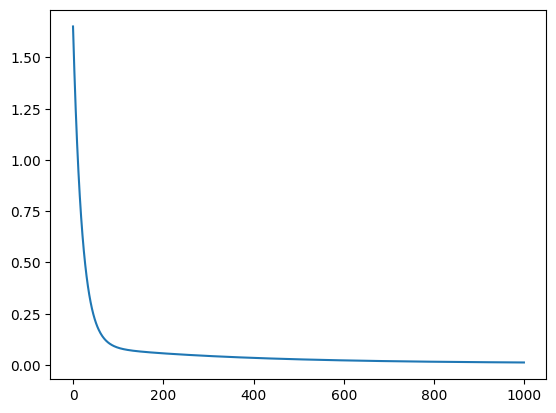

In [ ]:
import matplotlib.pyplot as plt
plt.plot(erreurs)

In [ ]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.7554]])), ('0.bias', tensor([1.1327]))])
